In [1]:
import os
import time
import random
import numpy as np
import pybullet as p
import pybullet_data
import trimesh
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from utils.utils import create_obj

def clear_files():
	for object_name in os.listdir(f"objects"):
		if object_name in ['sphere']:
			continue

		object_path = os.path.join("objects", object_name)
		for object_id in os.listdir(object_path):
			object_id_path = os.path.join(object_path, object_id)
			for f_name in os.listdir(object_id_path):
				f_path = os.path.join(object_id_path, f_name)
			
				# Check if it is a file (not a directory)
				if os.path.isfile(f_path):
					# Keep only files ending with .glb or .blend
					if not (f_name.endswith('.glb') or f_name.endswith('.blend')):
						try:
							os.remove(f_path)
						except Exception as e:
							print(f"Error deleting {f_path}: {e}")

object_specs = [
    ('table', 0.5, False),
    ('knife', 0.04, False),
    ('spoon', 0.04, False),
    ('fork', 0.04, False),
    ('apple', 0.2, False),
    ('banana', 0.2, False),
    ('pear', 0.2, False),
    ('mug', 0.5, True),
    ('paper-cup', 0.3, True),
    ('bowl', 0.4, True),
    ('box', 0.3, True),
    ('basket', 0.3, True),
    ('pan', 0.7, True)
]

# for name, mass, convex in object_specs:
#     create_obj(name, mass, convex)


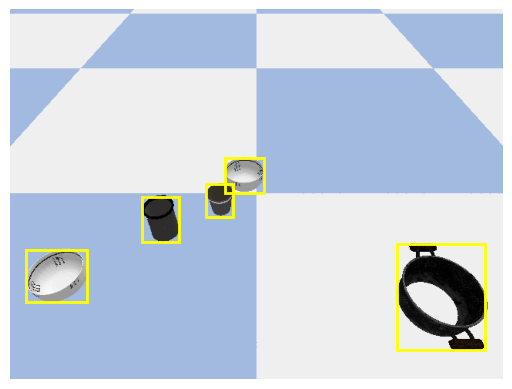

In [7]:
def random_pos(x_range, y_range, z_range):
    return [
        random.uniform(*x_range),
        random.uniform(*y_range),
        random.uniform(*z_range)
    ]

def load_object(name, pos, orn=[0, 0, 0], scale=1, obj_type=None, verbose=0):
    if obj_type is None:
        obj_type = random.randint(1, len(os.listdir(f"objects/{name}")))
    urdf_path = f"objects/{name}/{name}_{obj_type}/{name}_{obj_type}.urdf"
    obj_orn = p.getQuaternionFromEuler(orn)
    obj_id = p.loadURDF(urdf_path, pos, obj_orn, useFixedBase=False,
                        globalScaling=scale, flags=p.URDF_USE_MATERIAL_COLORS_FROM_MTL)
    p.changeVisualShape(obj_id, -1, rgbaColor=[1, 1, 1, 1])
    if verbose:
        print(f"Loaded object {name} at {pos}")
    return obj_id, obj_type

def load_table(grid_size, pos=[0, 0, 0], verbose=0):
    if grid_size == (100, 100):
        file_path = "objects/table/table_1.1/table_1.1.urdf"
    elif grid_size == (100, 300):
        file_path = "objects/table/table_1.3/table_1.3.urdf"
    else:
        raise ValueError("Invalid grid size. Supported sizes are (100, 100) and (100, 300).")
    table_id = p.loadURDF(file_path, pos, useFixedBase=True)
    p.changeVisualShape(table_id, -1, rgbaColor=[1, 1, 1, 1])
    if verbose > 0:
        print(f"Loaded table with grid_size {grid_size}")
    return table_id

class PyBulletSim:
    def __init__(self, mode=p.DIRECT):
        try:
            p.disconnect()
        except:
            pass

        self.client = p.connect(mode)
        p.setPhysicsEngineParameter(enableFileCaching=0)
        p.setAdditionalSearchPath(pybullet_data.getDataPath())
        p.resetSimulation()
        p.setGravity(0, 0, -9.8)
        p.setRealTimeSimulation(0)
        p.configureDebugVisualizer(p.COV_ENABLE_GUI, 0)
        p.loadURDF("plane.urdf")

        self.time_step = p.getPhysicsEngineParameters()['fixedTimeStep']

    def step(self, duration=0):
        for _ in range(int(duration / self.time_step)):
            p.stepSimulation()

    def close(self):
        if p.getConnectionInfo(self.client)['connectionMethod'] == p.GUI:
            while p.isConnected():
                p.stepSimulation()
                time.sleep(self.time_step)
        try:
            p.disconnect()
        except:
            pass

class Camera:
    def __init__(self, target_pos, distance, yaw, pitch, roll, width=640, height=480,
                 near=0.01, far=100, fov=60):
        self.target = target_pos
        self.distance = distance
        self.yaw, self.pitch, self.roll = yaw, pitch, roll
        self.width, self.height = width, height
        self.near, self.far = near, far
        self.fov = fov
        self.up_axis = 2

        p.resetDebugVisualizerCamera(
            cameraDistance=distance, 
            cameraTargetPosition=target_pos, 
            cameraYaw=yaw, cameraPitch=pitch
        )

        self.view_matrix = p.computeViewMatrixFromYawPitchRoll(
            self.target, self.distance, self.yaw, self.pitch, self.roll, self.up_axis)
        self.proj_matrix = p.computeProjectionMatrixFOV(
            self.fov, self.width/self.height, self.near, self.far)

        self.V = np.array(self.view_matrix).reshape(4, 4, order='F')
        self.P = np.array(self.proj_matrix).reshape(4, 4, order='F')

    def capture_image(self):
        _, _, rgb, _, _ = p.getCameraImage(
            self.width, self.height,
            viewMatrix=self.view_matrix,
            projectionMatrix=self.proj_matrix,
            renderer=p.ER_BULLET_HARDWARE_OPENGL)
        rgba = np.reshape(rgb, (self.height, self.width, 4)).astype(np.uint8)
        return rgba[:, :, :3]

    def project_points(self, world_points):
        N = world_points.shape[0]
        clip_pts = self.P @ (self.V @ np.vstack([world_points.T, np.ones(N)]))
        ndc = clip_pts / clip_pts[3]
        u = (ndc[0]*0.5 + 0.5) * self.width
        v = (1 - (ndc[1]*0.5 + 0.5)) * self.height
        return u, v

    def compute_bounding_box(self, obj_id, obj_name, obj_type, num_samples=500):
        mesh_path = f"objects/{obj_name}/{obj_name}_{obj_type}/{obj_name}_{obj_type}.obj"
        mesh = trimesh.load_mesh(mesh_path)
        points, _ = trimesh.sample.sample_surface(mesh, num_samples)
        pos, orn = p.getBasePositionAndOrientation(obj_id)
        R = trimesh.transformations.quaternion_matrix([orn[3], *orn[:3]])[:3, :3]
        world_pts = (R @ points.T).T + np.array(pos)
        u, v = self.project_points(world_pts)
        u_min, u_max = u.min(), u.max()
        v_min, v_max = v.min(), v.max()
        return (u_min, u_max, v_min, v_max)

    def draw_bounding_boxes(self, image, boxes=[], color='yellow'):
        fig, ax = plt.subplots(figsize=(self.width / 100, self.height / 100), dpi=100)
        ax.imshow(image)
        for (u_min, u_max, v_min, v_max) in boxes:
            rect = patches.Rectangle((u_min, v_min), u_max - u_min, v_max - v_min,
                                     linewidth=2, edgecolor=color, facecolor='none')
            ax.add_patch(rect)
        plt.axis('off')
        plt.show()

sim = PyBulletSim(p.DIRECT)
cam = Camera(target_pos=[0.5, 0, 0.5], distance=0.4, yaw=90, pitch=-45, roll=0)

bboxs = []
for obj_name in ['mug', 'bowl', 'pan', 'paper-cup', 'bowl']:
	obj_id, obj_type = load_object(obj_name, random_pos([-0.5, 0.5], [-0.5, 0.5], [0.05, 0.05]))
	bboxs.append(cam.compute_bounding_box(obj_id, obj_name, obj_type))

image = cam.capture_image()
cam.draw_bounding_boxes(image, bboxs)
sim.close()